In [1324]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

In [1325]:
### Helper Functions ###


def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)

    # Calculate number of rows
    rows = math.ceil(num_images / cols)

    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over

    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(
                images[i], cmap="gray" if len(images[i].shape) == 2 else None
            )

            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis("off")

        # Remove axes for clarity
        axes[i].axis("off")

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()


def laplacian_sharpening(img):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)

    return cv2.filter2D(img, -1, kernel)


def red_color_thresholding(image):
    # Convert the image to the HSV color space.
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    min_lower_red = np.array([0, 50, 50])
    max_lower_red = np.array([5, 255, 255])

    min_upper_red = np.array([165, 50, 50])
    max_upper_red = np.array([180, 255, 255])

    # Create mask for both red ranges.
    lower_red_mask = cv2.inRange(hsv, min_lower_red, max_lower_red)
    upper_red_mask = cv2.inRange(hsv, min_upper_red, max_upper_red)

    # Combine the two masks to capture both.
    mask = cv2.bitwise_or(lower_red_mask, upper_red_mask)

    return mask

# Task 1

In [1326]:
data_dir = "./Task-1"

sign_path = os.path.join(data_dir, "rh_sign.jpg")
sign_image = cv2.imread(sign_path)

scene_paths = [os.path.join(data_dir, image) for image in ["img1.png", "img2.png", "img3.png", "img4.png", "img5.png"]]
scene_images = [cv2.imread(path) for path in scene_paths]

In [1327]:
def get_reference_contour(sign_image):
    """Extract contour from reference sign image"""
    
    gray = cv2.cvtColor(sign_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contours found in template")

    
    cv2.drawContours(thresh, contours, -1, (0,255,0), 2)
    reference_contour = max(contours, key=cv2.contourArea)

    return reference_contour, thresh


def is_triangle(contour, tolerance=0.04):
    """Check if a contour is a triangle using polygon approximation."""
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, tolerance * perimeter, True)
    return len(approx) == 3, approx  # Return whether it's a triangle and the approximation


def locate_rh_sign(sign_image, scene_image):
    """Detect the most similar triangle contour to the reference sign."""

    
    reference_contour, thresh = get_reference_contour(sign_image)
    
    # Convert image to grayscale
    scene_image_gray = cv2.cvtColor(scene_image, cv2.COLOR_BGR2GRAY)
    
    # Binary thresholding
    _, binary_thresh = cv2.threshold(scene_image_gray, 127, 255, cv2.THRESH_BINARY)
    
    # Adaptive thresholding
    adaptive_thresh = cv2.adaptiveThreshold(scene_image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                  cv2.THRESH_BINARY, 11, 2)
    
    # Edge detection
    edges = cv2.Canny(scene_image_gray, 30, 150)
    
    # Red color thresholding
    red_mask = red_color_thresholding(scene_image)
    
    preprocessed_images = [binary_thresh, adaptive_thresh, edges, red_mask]
    best_detection = None  # Track the best detection

    for idx, processed in enumerate(preprocessed_images):
        contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for contour in contours:
            # Ignore tiny contours.
            if cv2.contourArea(contour) < 100:
                continue
            
            # Check if contour is like triangle.
            is_tri, approx = is_triangle(contour)
            if not is_tri:
                continue

            similarity = cv2.matchShapes(reference_contour, approx, cv2.CONTOURS_MATCH_I2, 0.0)

            similarity_threshold = 0.2
 
            if similarity < similarity_threshold:
                x, y, w, h = cv2.boundingRect(contour)
                detection = (x - 4, y - 4, w + 8, h + 8, similarity)
                
                # Update the best detection based on similarity
                if best_detection is None or similarity < best_detection[4]:
                    best_detection = detection

    if best_detection:
        final_image = scene_image.copy()

        x, y, w, h, similarity = best_detection

        cv2.rectangle(final_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

        plot_images(
            images=[bgr_to_rgb(scene_image), bgr_to_rgb(final_image)],
            titles=["Image", "Image with Highlighted Road Sign"],
            cols=2,
            figsize=(10, 5)
        )
    else:
        print("No triangles detected with sufficient similarity.")

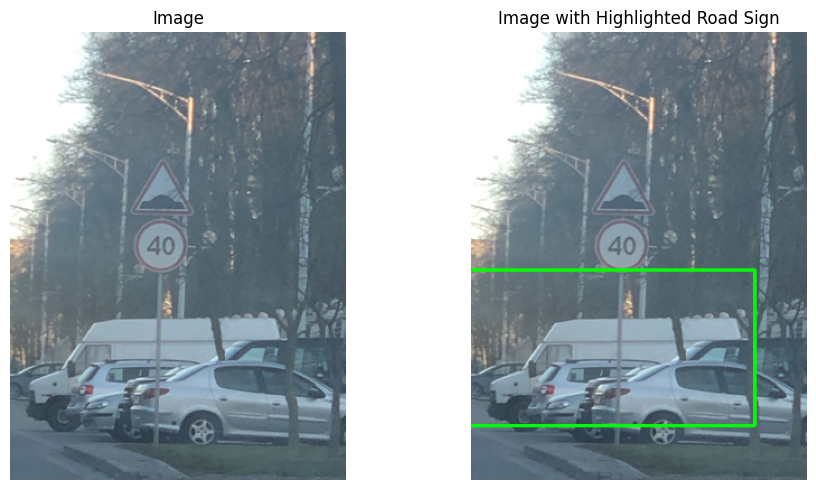

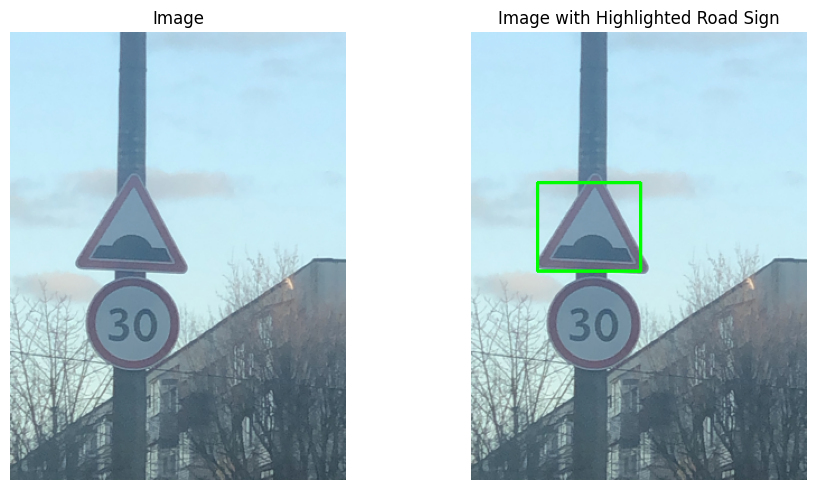

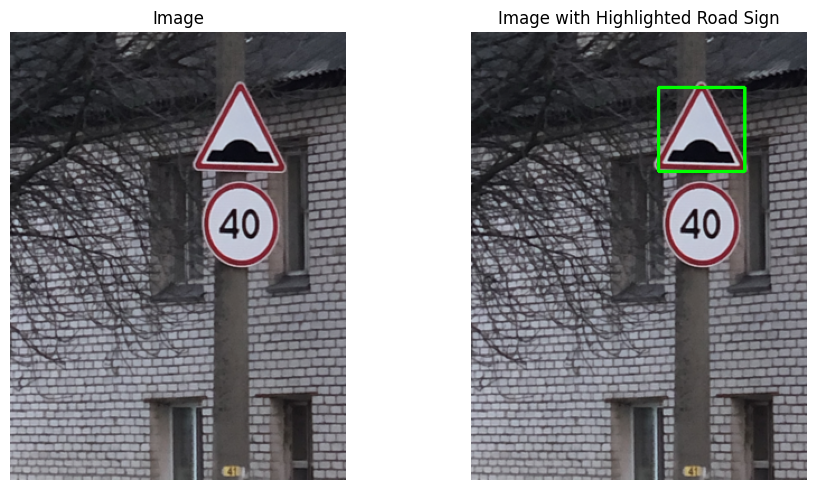

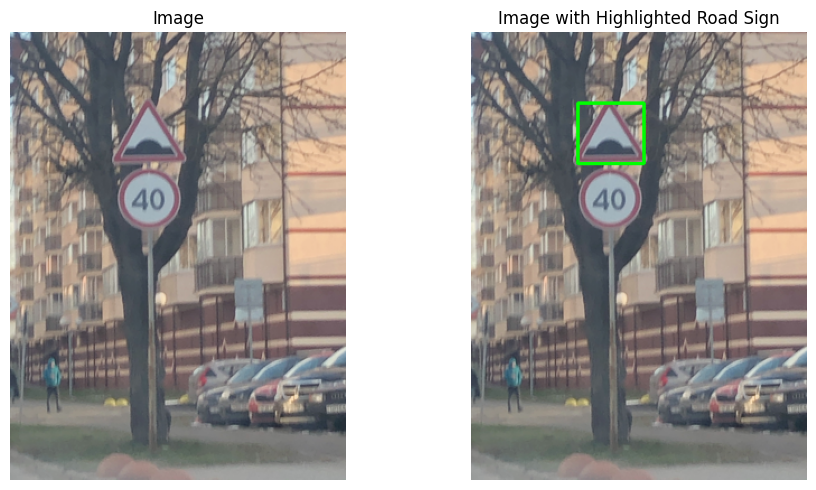

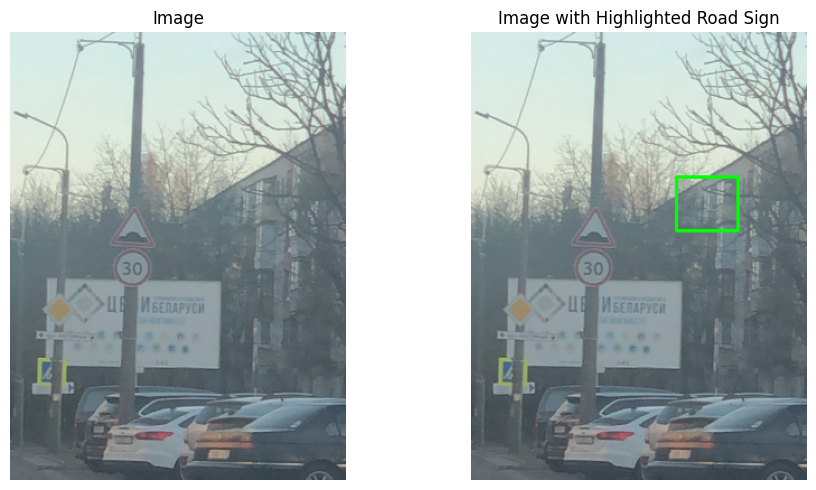

In [1328]:
for scene_image in scene_images:
    locate_rh_sign(sign_image, scene_image)

# Task 2

In this task, we first applied the Discrete Fourier Transform (DFT) to convert the image from the spatial domain to the frequency domain. In the frequency domain, artifacts like the horizontal lines (like from the blinds in the provided image) appear as high-energy frequency components. By searching for these high-energy components and cancelling them out, we can effectively remove such artifacts.

To filter out these unwanted frequency components, we used a Gabor filter on each colour channel. A Gabor filter can be viewed as a sinusoidal signal of particular frequency and orientation, modulated by a Gaussian wave [[1]](https://medium.com/@anuj_shah/through-the-eyes-of-gabor-filter-17d1fdb3ac97). By creating a Gabor filter that is horizontally orientated and matches the frequency of the horizontal blinds, then applying the DFT to it, then multiplying the filter element-wise with the image in the frequency domain we can efficiently and effectively apply the filter.

Doing the calculation in the frequency domain has multiple benefits. Firstly, we get faster computations because we do not have to convolve the filter over the image. Secondly, we get better results because, in the frequency domain, the periodic pattern of the blinds in the whole image is reduced to a single spike. Thus broad patterns are more effectively cancelled out. In the spatial domain, the Gabor filter would only have access to the pattern in the pixels it is currently convolving over.

Once we applied the filter, we used the inverse Fourier Transform to convert each colour channel back to spatial domain. We normalisation and denoising on each channel and then merged them. Finally, we applied some Laplacian sharpening on the image - although its effect was very subtle.

In [1329]:
data_dir = "./Task-2"
image_path = os.path.join(data_dir, "AF1.jpg")
image = cv2.imread(image_path)

In [1330]:
def remove_blinds(image):
    kernel_size = 37

    # Create Gabor kernel for horizontal line detection.
    gabor_kernel = cv2.getGaborKernel(
        ksize=(kernel_size, kernel_size),
        sigma=3.0,
        theta=0,
        lambd=17.5,
        gamma=0.5,
        psi=0,
        ktype=cv2.CV_32F
    )

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Compute the Fourier Transform of the grayscale image.
    dft_image = np.fft.fft2(gray_image)
    # Shift the zero frequency to the center.
    dft_image_shifted = np.fft.fftshift(dft_image)
    # Compute the magnitude of each Fourier coefficient.
    magnitude_spectrum = np.abs(dft_image_shifted)
    # Apply log scaling so higher frequency components do
    # not overpower the lower frequency ones. Thus we compress
    # the dynamic range of the magnitude spectrum.
    magnitude_spectrum = np.log(magnitude_spectrum + 1)

    # Process each channel separately
    filtered_channels = []

    for channel in cv2.split(image):
        ### Compute the Fourier Transform of the colour channel ###
        dft_channel = np.fft.fft2(channel)
        # Shift the zero frequency to the center.
        dft_channel_shifted = np.fft.fftshift(dft_channel)

        ### Compute the Fourier Transform of the Gabor filter. ###
        # Padding the Gabor kernel to match the size of the channel.
        padded_gabor_kernel = np.zeros_like(channel, dtype=np.float64)
        k_center = kernel_size // 2
        padded_gabor_kernel[:kernel_size, :kernel_size] = gabor_kernel
        # Center the kernel by rolling it to the middle of the padded array.
        padded_gabor_kernel = np.roll(padded_gabor_kernel, -k_center, axis=0)
        padded_gabor_kernel = np.roll(padded_gabor_kernel, -k_center, axis=1)
        # Compute the Fourier Transform of the padded Gabor kernel to convert iage into the frequency domain.
        dft_gabor_kernel = np.fft.fft2(padded_gabor_kernel)
        # Shift the zero-frequency component (DC component) of the Gabor kernel's Fourier Transform
        # to the center of the spectrum for alignment with the image's Fourier Transform.
        dft_gabor_kernel_shifted = np.fft.fftshift(dft_gabor_kernel)

        ### Perform element-wise multiplication in the frequency domain. ###
        # This applies the Gabor filter in the frequency domain.
        filtered_dft = dft_channel_shifted * dft_gabor_kernel_shifted

        # Inverse Fourier Transform to get the filtered image back in spatial domain.
        filtered_dft_shifted_back = np.fft.ifftshift(filtered_dft)
        filtered_image = np.fft.ifft2(filtered_dft_shifted_back)
        filtered_image_real = np.real(filtered_image)

        # Normalize the filtered colour channel to the range [0, 255].
        filtered_channel_normalized = cv2.normalize(filtered_image_real, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Apply denoising to the normalized channel to reduce noise artifacts.
        filtered_channel_normalized = cv2.fastNlMeansDenoising(filtered_channel_normalized)

        filtered_channels.append(filtered_channel_normalized)

    # Merge the processed channels back together
    return magnitude_spectrum, bgr_to_rgb(cv2.merge(filtered_channels))

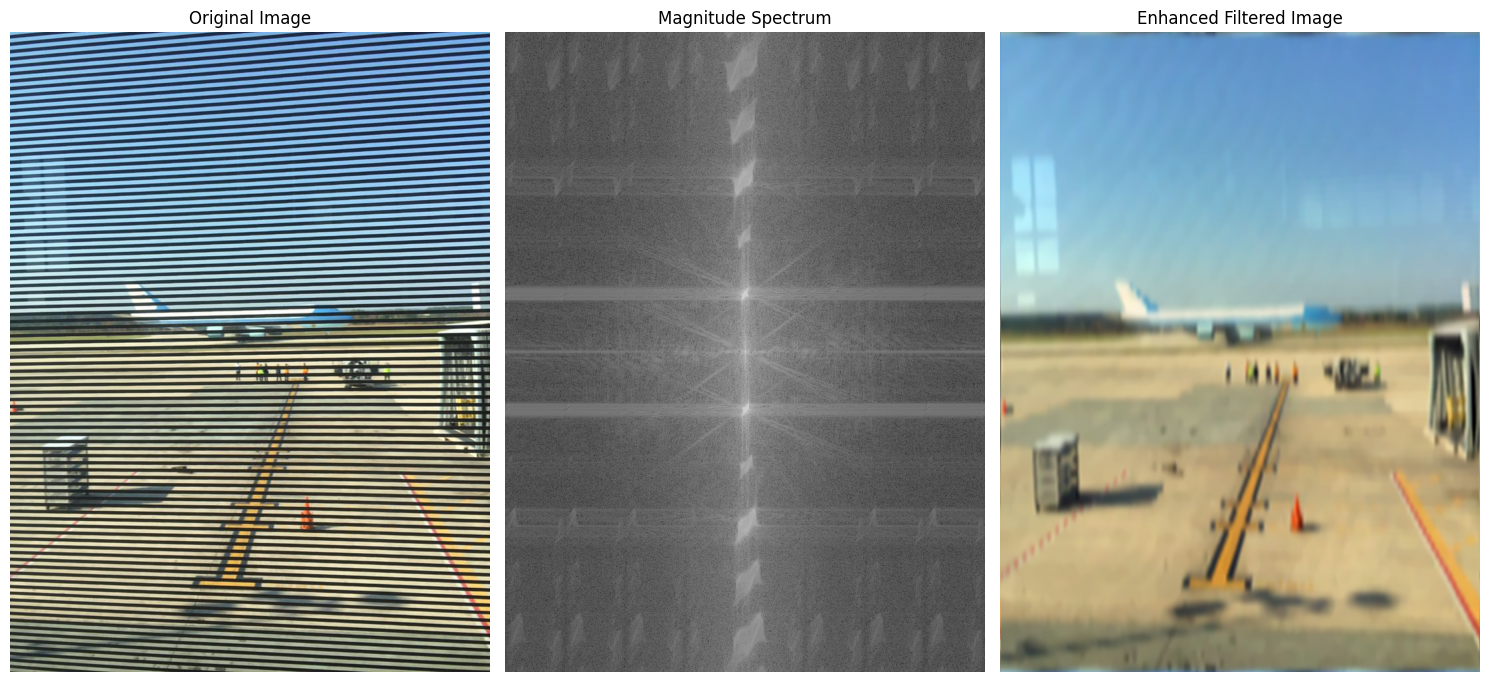

In [1331]:
magnitude_spectrum, result = remove_blinds(image)

plot_images(
    images=[bgr_to_rgb(image), magnitude_spectrum, laplacian_sharpening(result)],
    titles=["Original Image", "Magnitude Spectrum", "Enhanced Filtered Image"],
)

# Task 3

Before the automatic alignment is done, the desired region of interest (ROI) is extracted from the image using binary thresholding. This is especially important for "zebra_crossing2.png" where a large part of the image is just a black filler. Once the ROI is extracted, the image is cropped such that only the ROI remains, then it is resized to be the same size as the reference image. This greatly increases the quality of features detected for both images.

Once the images have been preprocessed, we used ORB to extract and match features from both the reference and target image. Finally, we perform a homography to transfer the target image onto the reference image, performing a perspective transformation that aligns the target image with the reference image. This process allows us to warp the target image, correcting for any changes in viewpoint or perspective between the two images.

Many post-processing steps were attempted to remove the jagged edge artifacts in "zebra_crossing2.png" (including anti-aliasing and resampling) however none were effective as the image had been heavily distorted with a lot of information lost.

Whilst you could get really good results with manual correspondence selection, the automatic was 90% as good with a lot less effort. "zebra_crossing2.png" was especially hard to match up manually. Automatic correspondence selection was also a lot quicker and more consistent.

In [1332]:
data_dir = "./Task-3"

source_paths = [os.path.join(data_dir, image) for image in ["zebra_crossing1.png", "zebra_crossing2.png"]]
sources = [cv2.imread(path) for path in source_paths]

target_path = os.path.join(data_dir, "zebra_crossing_reference.jpg")
target = cv2.imread(target_path)

In [1333]:
def extract_roi(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Threshold the image to create a binary image (non-black areas will be white).
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    
    # Find contours of the non-black areas.
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Find the bounding box of the largest contour (which should be the region of interest).
    x, y, w, h = cv2.boundingRect(contours[0])
    
    return x, y, w, h


# Crop the image to the bounding box (ROI)
def crop_image(image, x, y, w, h):
    return image[y:y+h, x:x+w]

In [1334]:
def manually_align_images(source_color, source_gray, target_color, target_gray):
    def select_points(image, window_name):
        points = []
        drawing = [image.copy()]

        def draw_and_select(event, x, y, flags, param):
            if event == cv2.EVENT_LBUTTONDOWN:
                points.append((x, y))

                # Draw point
                for i, pt in enumerate(points):
                    cv2.circle(drawing[0], pt, 5, (0, 255, 0), -1)

                cv2.imshow(window_name, drawing[0])  # Update the image display

        # Display the image for point selection
        cv2.imshow(window_name, image)
        cv2.setMouseCallback(window_name, draw_and_select)

        # Wait for the user to finish point selection by pressing Enter
        while True:
            key = cv2.waitKey(1) & 0xFF
            if key == 13:  # Enter key
                break

        cv2.destroyWindow(window_name)
        return points

    # Select points for the source image
    source_points = select_points(source_color, "Select Points (min 4) then press Enter - Source Image")

    # Select points for the target image
    target_points = select_points(target_color, "Select Points (min 4) then press Enter - Target Image")

    # Convert points to NumPy arrays
    src_pts = np.float32(source_points).reshape(-1, 1, 2)
    tgt_pts = np.float32(target_points).reshape(-1, 1, 2)

    # Compute the homography matrix
    H, mask = cv2.findHomography(src_pts, tgt_pts, cv2.RANSAC, 5.0)

    # Warp the source image
    height, width = target_gray.shape
    aligned_source = cv2.warpPerspective(source_color, H, (width, height))

    # Create a combined image for SIFT-style visualization
    combined_width = source_color.shape[1] + target_color.shape[1]
    combined_height = max(source_color.shape[0], target_color.shape[0])
    combined_img = np.zeros((combined_height, combined_width, 3), dtype=np.uint8)

    # Place source and target images side by side
    combined_img[:source_color.shape[0], :source_color.shape[1]] = source_color
    combined_img[:target_color.shape[0], source_color.shape[1]:] = target_color

    # Draw the points and connecting lines
    for (sx, sy), (tx, ty) in zip(source_points, target_points):
        # Draw source points (green dots)
        cv2.circle(combined_img, (int(sx), int(sy)), 5, (0, 255, 0), -1)

        # Draw target points (red dots)
        cv2.circle(combined_img, (int(tx) + source_color.shape[1], int(ty)), 5, (0, 0, 255), -1)

        # Draw connecting lines (blue)
        cv2.line(combined_img, (int(sx), int(sy)), (int(tx) + source_color.shape[1], int(ty)), (255, 0, 0), 2)

    return aligned_source, combined_img

In [1335]:
def automatically_align_images(source_color, source_gray, target_color, target_gray):
    target_height, target_width = target_gray.shape

    # Extract ROI from target image (remove the black box if needed)
    x, y, w, h = extract_roi(source_color)

    # Crop the images based on ROI
    source_color = crop_image(source_color, x, y, w, h)
    source_gray = crop_image(source_gray, x, y, w, h)

    # Resize back up to target image size
    source_color = cv2.resize(source_color, (target_width, target_height))
    source_gray = cv2.resize(source_gray, (target_width, target_height))

    orb = cv2.ORB_create()

    # Detect keypoints and descriptors
    source_kp, source_des = orb.detectAndCompute(source_gray, None)
    target_kp, target_des = orb.detectAndCompute(target_gray, None)

    # Match descriptors using BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING2, crossCheck=True)
    matches = bf.match(source_des, target_des)
    
    # Sort matches by distance (best matches first)
    matches = sorted(matches, key=lambda x: x.distance)

    # Extract the corresponding points
    source_pts = np.float32([source_kp[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    target_pts = np.float32([target_kp[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Compute the homography
    H, mask = cv2.findHomography(source_pts, target_pts, cv2.RANSAC, 5.0)

    # Warp the source image to align with the target
    aligned_source = cv2.warpPerspective(source_color, H, (target_width, target_height))

    # Draw the matches.
    matched_img = cv2.drawMatches(source_color, source_kp, target_color, target_kp, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    return aligned_source, matched_img

In [1336]:
def align_images(source, target, selection="automatic"):
    source_gray = cv2.cvtColor(source, cv2.COLOR_BGR2GRAY)
    target_gray = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)

    # Feature detection and matching
    if selection == "automatic":
        aligned_source, matched_img = automatically_align_images(
            source, source_gray, target, target_gray
        )
    elif selection == "manual":
        aligned_source, matched_img = manually_align_images(
            source, source_gray, target, target_gray
        )

    plot_images(
        images=[
            bgr_to_rgb(source),
            bgr_to_rgb(target),
            bgr_to_rgb(matched_img),
            bgr_to_rgb(aligned_source),
        ],
        titles=["source", "target", "Matched Points", "Transformed/aligned source"],
        cols=4
    )

AUTOMATIC


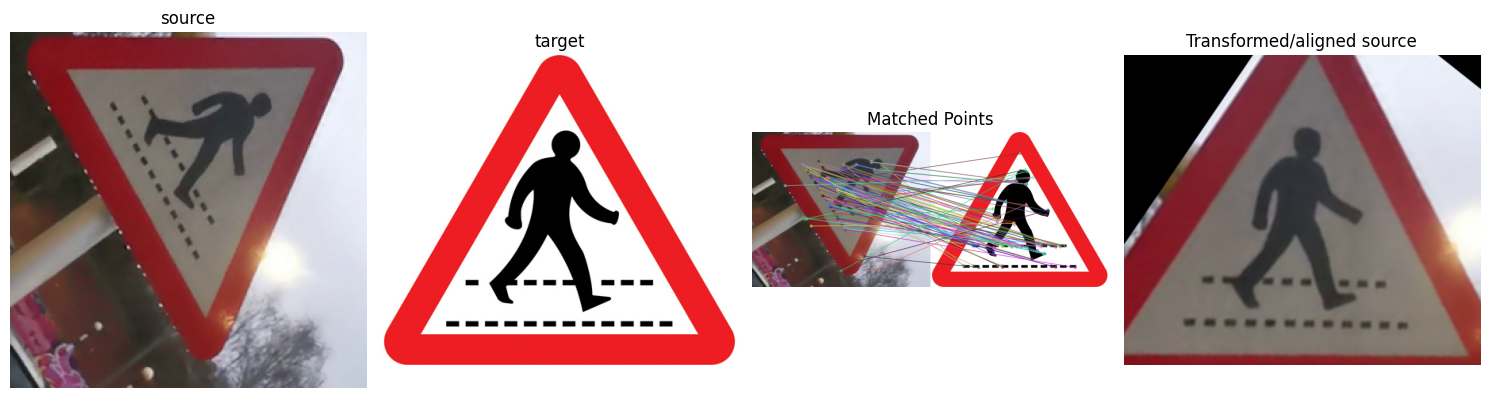

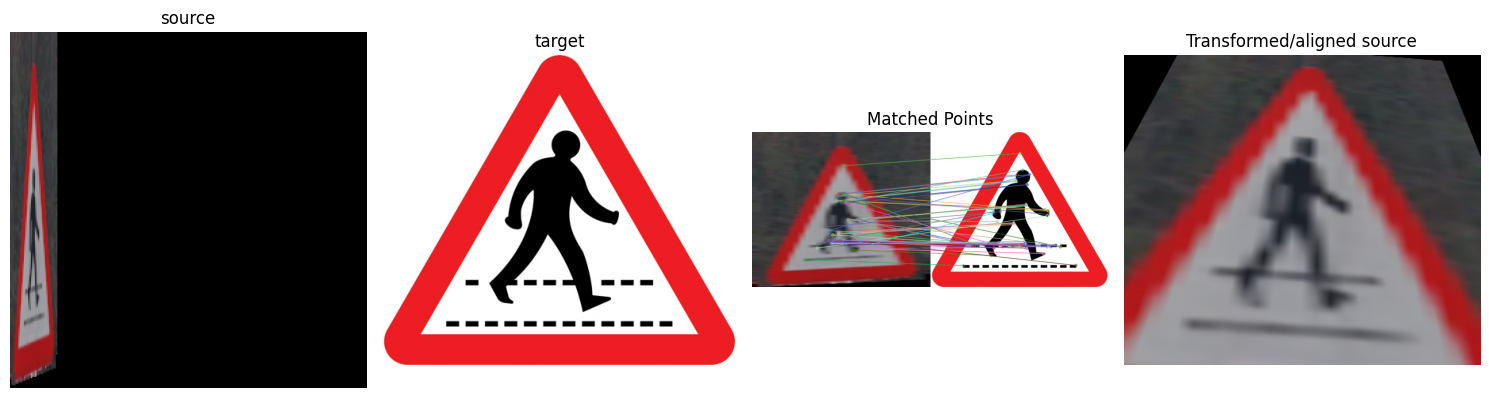

In [1337]:
# Uncomment for manual. Results will be displayed below.
# Press Enter after finishing point selection for source/target.
# Ensure same number of points are selected each time and in the same order.

# print("MANUAL")
# for source in sources:
#     align_images(source, target, "manual")

print("AUTOMATIC")
for source in sources:
    align_images(source, target, "automatic")

# Task 4


In [1338]:
data_dir = "./Task-4"

image_paths = [os.path.join(data_dir, image) for image in ["frail.png", "road_humps_1.png", "road_humps_2.png", "road_works.png", "zebra_crossing.png"]]
images = [cv2.imread(path) for path in image_paths]

In [1339]:
def get_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Assuming you're working with the largest contour (you can adjust as needed)
    largest_contour = max(contours, key=cv2.contourArea)

    return largest_contour


def is_within_10_percent(old_value, new_value):
    lower_bound = old_value * 0.9
    upper_bound = old_value * 1.1

    return lower_bound <= new_value and new_value <= upper_bound


def check_contour_area_diff(old, new):
    return is_within_10_percent(
        cv2.contourArea(get_largest_contour(old)),
        cv2.contourArea(get_largest_contour(new)),
    )

In [1340]:
def denoise(mask):
    kernel = np.ones((11, 11), np.uint8)

    # Apply opening (erosion followed by dilation) to remove small noise.
    cleaned_image = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    kernel = np.ones((5, 5), np.uint8)

    # Apply closing (dilation followed by erosion) to fill small holes.
    cleaned_image = cv2.morphologyEx(cleaned_image, cv2.MORPH_CLOSE, kernel)

    return cleaned_image


def fill_mask(mask):
    largest_contour = get_largest_contour(mask)

    new_mask = np.zeros_like(mask)

    cv2.drawContours(new_mask, [largest_contour], -1, (255), thickness=cv2.FILLED)

    return new_mask


def create_triangle_encompassing_mask(mask):
    largest_contour = get_largest_contour(mask)

    # Create a blank mask of the same size as the input mask.
    triangle_mask = np.zeros_like(mask)

    # Fit a triangle around the contour.
    triangle_pts = cv2.minEnclosingTriangle(largest_contour)[1]

    # Draw the triangle on the image.
    triangle_pts = np.int32(triangle_pts)

    # Ensure the points are in the right shape (Nx1x2).
    triangle_pts = triangle_pts.reshape((-1, 1, 2))

    # Draw the triangle on the mask.
    cv2.drawContours(triangle_mask, [triangle_pts], -1, (255), thickness=cv2.FILLED)

    return triangle_mask


def segment_warning_road_sign(image):
    thresholded_mask = red_color_thresholding(image)
    denoised_mask = denoise(thresholded_mask)

    no_disconnect = check_contour_area_diff(thresholded_mask, denoised_mask)

    # Fallback to thresholded mask if smoothing causes contour to disconnect
    mask = denoised_mask if no_disconnect else thresholded_mask

    filled_mask = fill_mask(mask)

    no_fill = is_within_10_percent(np.sum(mask == 255), np.sum(filled_mask == 255))

    # Fallback to crude triangle drawing if contour could not be filled.
    mask = create_triangle_encompassing_mask(mask) if no_fill else filled_mask

    # plot_images([thresholded_mask, denoised_mask, filled_mask, mask])

    # Segment the foreground image using the sign mask (keeping only the sign)
    segmented_foreground = cv2.bitwise_and(image, image, mask=mask)

    return mask, segmented_foreground

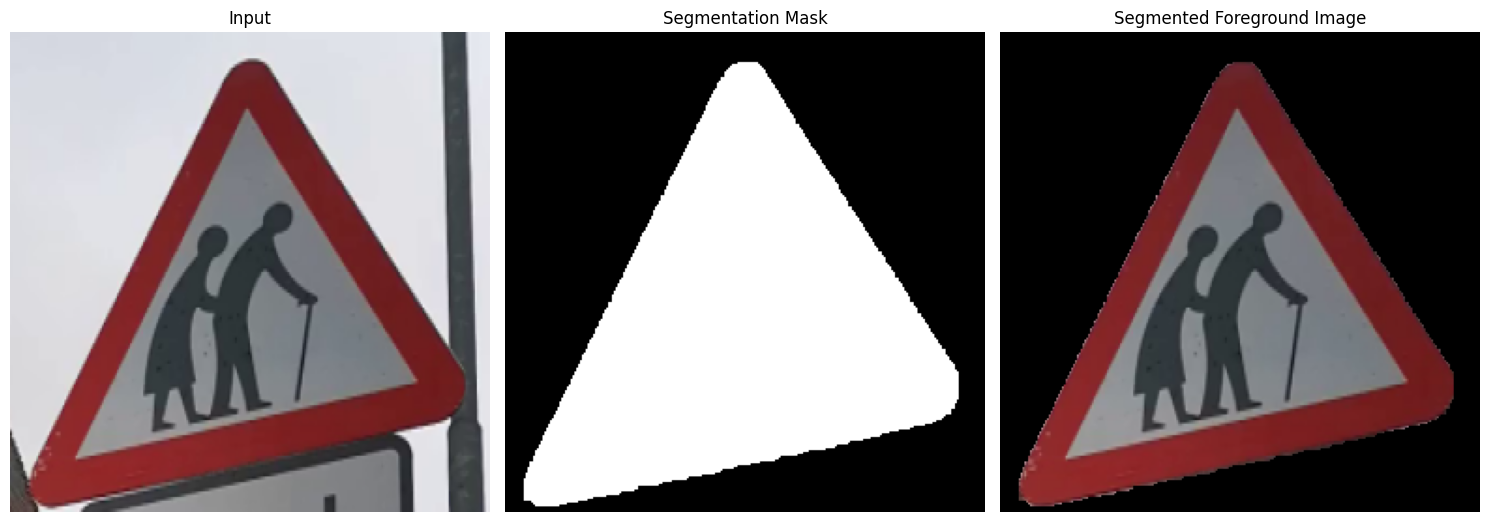

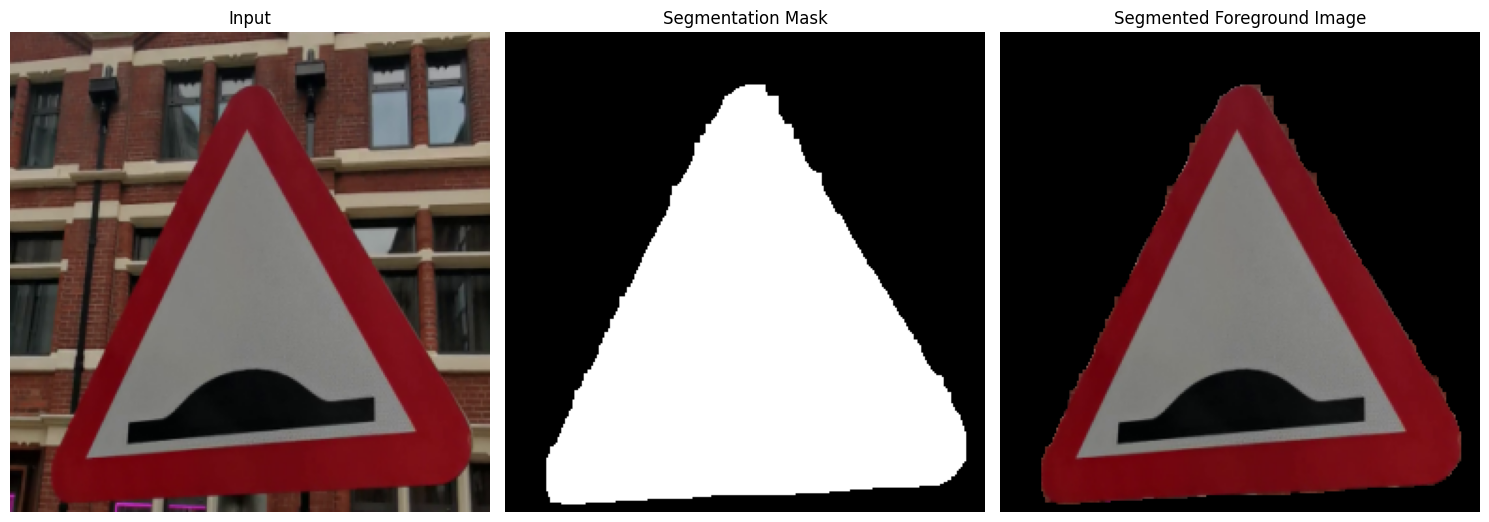

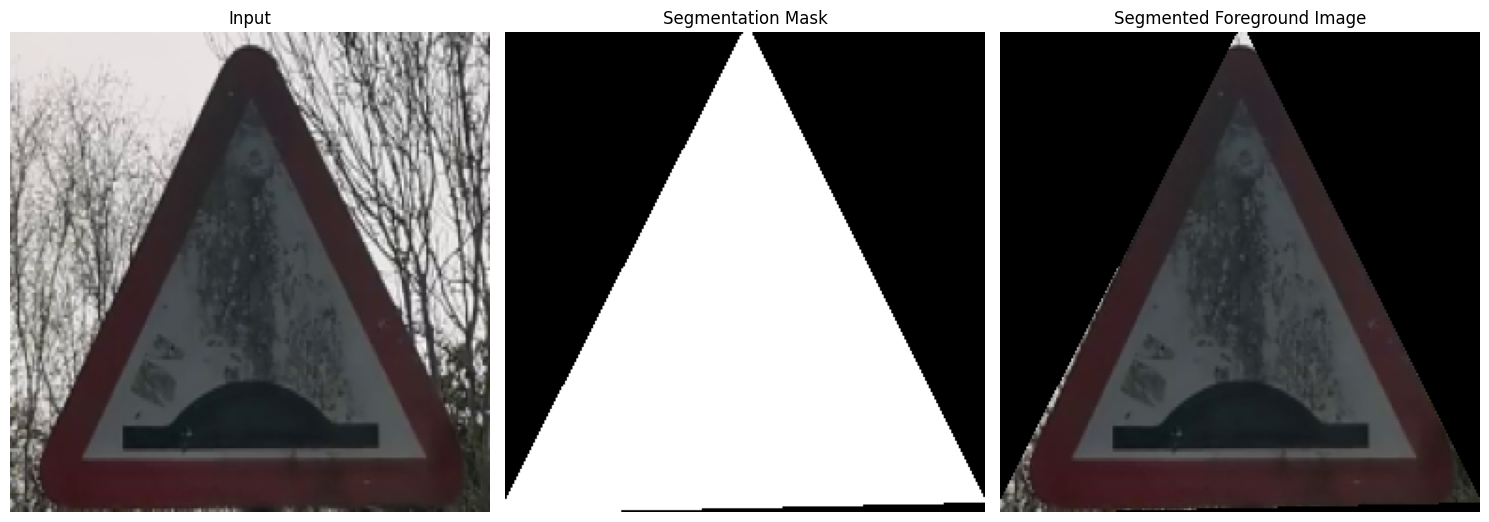

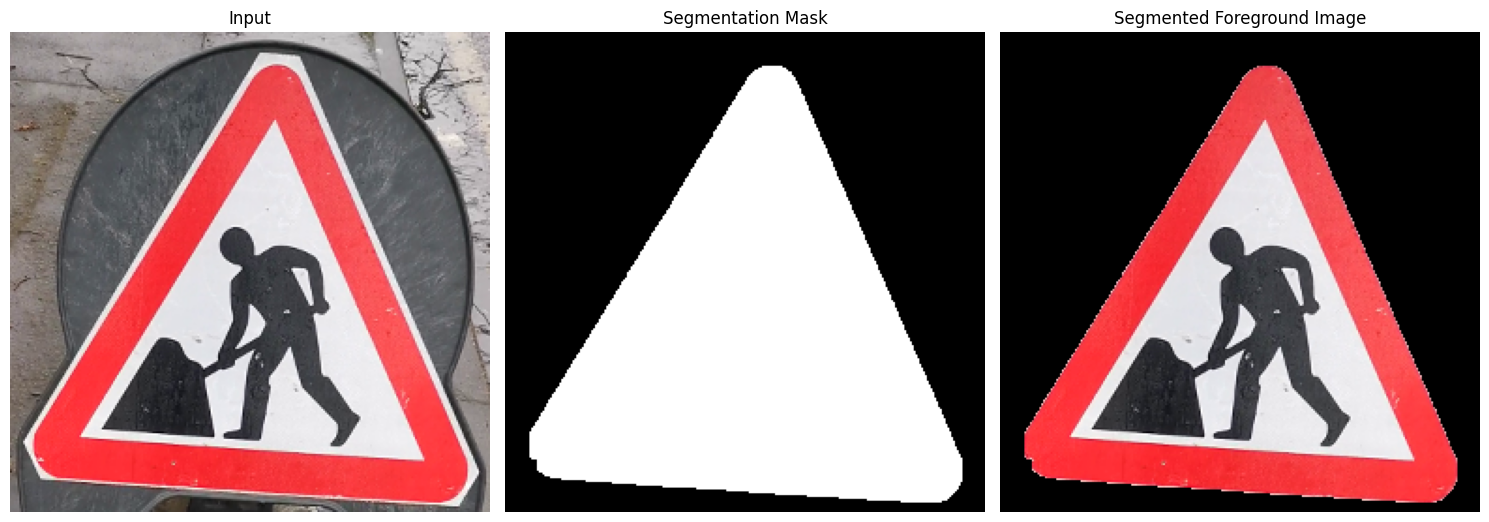

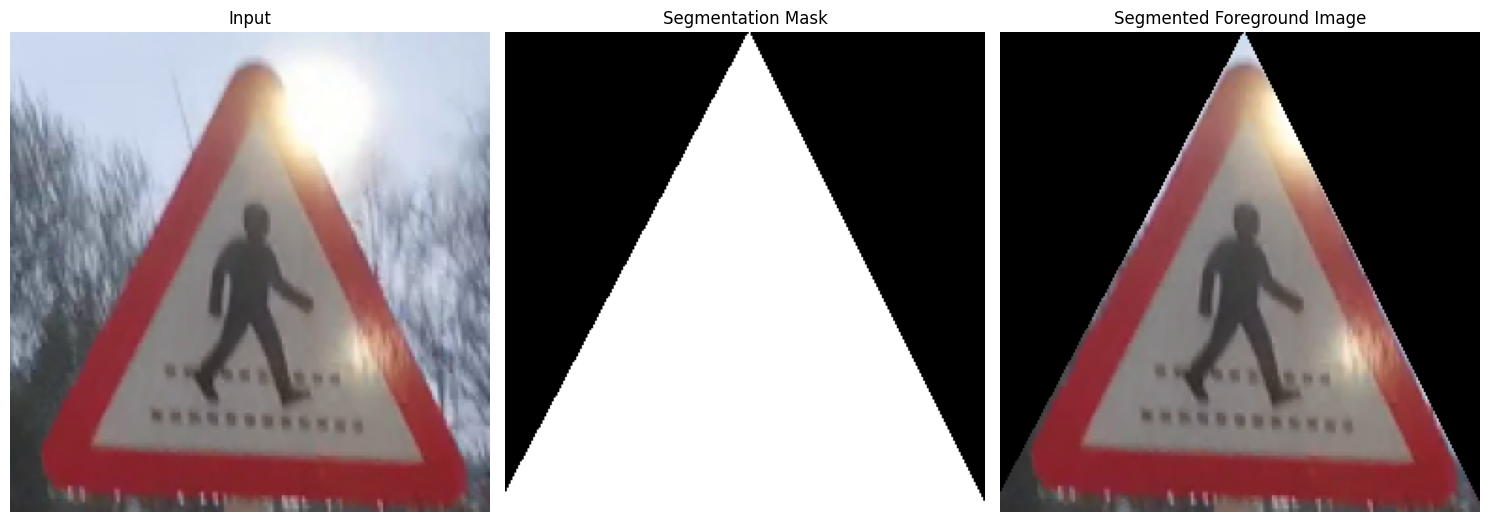

In [1341]:
for image in images:
    segmentation_mask, segmented_foreground_image = segment_warning_road_sign(image)
    plot_images(
        images=[bgr_to_rgb(image), segmentation_mask, bgr_to_rgb(segmented_foreground_image)],
        titles=["Input", "Segmentation Mask", "Segmented Foreground Image"],
    )